In [1]:
import numpy as np
from pathlib import Path

from scipy.special import gammaln

In [2]:
def neg_log_likelihood(
    rates: np.ndarray,
    spikes: np.ndarray,
    zero_warning: bool = True,
) -> float:
    """
    Calculates Poisson negative log likelihood given rates and spikes.
    Formula: -log(e^(-r) / n! * r^n) = r - n*log(r) + log(n!)

    Args:
        rates: numpy array containing rate predictions
        spikes: numpy array containing true spike counts
        zero_warning: whether to print out warnings about 0 rate predictions

    Returns:
        Total negative log-likelihood of the data
    """
    assert spikes.shape == rates.shape, (
        f"neg_log_likelihood: Rates and spikes should be of the same shape. "
        f"spikes: {spikes.shape}, rates: {rates.shape}"
    )

    if np.any(np.isnan(spikes)):
        mask: np.ndarray = np.isnan(spikes)
        rates = rates[~mask]
        spikes = spikes[~mask]

    assert not np.any(np.isnan(rates)), "neg_log_likelihood: NaN rate predictions found"
    assert np.all(rates >= 0), "neg_log_likelihood: Negative rate predictions found"

    if np.any(rates == 0):
        if zero_warning:
            logger.warning("neg_log_likelihood: Zero rate predictions found. Replacing zeros with 1e-9")
        rates = rates.copy()
        rates[rates == 0] = 1e-9

    result: np.ndarray = rates - spikes * np.log(rates) + gammaln(spikes + 1.0)
    return float(np.sum(result))


def bits_per_spike(rates: np.ndarray, spikes: np.ndarray) -> float:
    """
    Computes bits per spike of rate predictions given spikes.

    Args:
        rates: 3D numpy array of rate predictions
        spikes: 3D numpy array of true spike counts

    Returns:
        Bits per spike value
    """
    nll_model: float = neg_log_likelihood(rates, spikes)
    null_rates: np.ndarray = np.tile(
        np.nanmean(spikes, axis=tuple(range(spikes.ndim - 1)), keepdims=True),
        spikes.shape[:-1] + (1,),
    )
    nll_null: float = neg_log_likelihood(null_rates, spikes, zero_warning=False)
    return float((nll_null - nll_model) / np.nansum(spikes) / np.log(2))

In [3]:
base_dir = Path("/work/hdd/beez/ywang74/Project/video-spike/results_encoding")

model_name_list = ["kp", "pca", "cebra", "beast-tfs"]

dataset_name_list = ["ibl-left", "ibl-whisker", "facemap"]

In [4]:
final_dict = {}

for model_name in model_name_list:

    final_dict[model_name] = {}

    res_dir = base_dir / model_name

    dataset_dict = {}

    for dataset_name in dataset_name_list:

        dataset_dict[dataset_name] = {}

        metric_path = res_dir / f"{model_name}_{dataset_name}.npy"

        try:
            dataset = np.load(metric_path, allow_pickle=True).item()
        except Exception as e:
            print(f"Error loading {metric_path}: {e}")
            continue

        metric_dict = {"rrr": [], "cnn": []}
        for eid in dataset.keys():
            for decoder in ["rrr", "cnn"]:
                gt = dataset[eid][decoder]["gt"]
                pred = dataset[eid][decoder]["pred"]
                if "facemap" not in str(metric_path):
                    for neuron_idx in range(gt.shape[-1]):
                        metric_dict[decoder].append(bits_per_spike(pred[..., neuron_idx], gt[..., neuron_idx]))
                else:
                    metric_dict[decoder].append(dataset[eid][decoder]["r2"])

        dataset_dict[dataset_name] = metric_dict

    final_dict[model_name] = dataset_dict

final_dict["kp"]["ibl-whisker"]["rrr"] = np.zeros_like(final_dict["kp"]["ibl-left"]["rrr"])
final_dict["kp"]["ibl-whisker"]["cnn"] = np.zeros_like(final_dict["kp"]["ibl-left"]["cnn"])

Error loading /work/hdd/beez/ywang74/Project/video-spike/results_encoding/kp/kp_ibl-whisker.npy: [Errno 2] No such file or directory: '/work/hdd/beez/ywang74/Project/video-spike/results_encoding/kp/kp_ibl-whisker.npy'


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def mean_se(x):
    """Return (mean, SE, n) with NaN-safe behavior."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n == 0:
        return np.nan, np.nan, 0
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
    return m, se, n

def plot_bars(
    final_dict,
    model_order=("kp", "pca", "cebra", "beast"),
    model_display=("Keypoints", "PCA", "CEBRA", "BEAST"),
    dataset_names=("ibl-left", "ibl-motion-energy", "ibl-facemap"),  # adjust to your keys
    ylabels=("Bits Per Spike", "Bits Per Spike", "Variance Explained"),
    decoder_order=("rrr", "cnn"),
    decoder_display=("RRR", "TCN"),
    colors=("0.85", "#ffb38a", "#7fa8ff", "#9be39b"),  # one color per model
    hatches=("///", None),  # hatch for RRR, solid for CNN
    figsize=(4.2, 6.2),
    ylim_list=((0, 0.18), (0, 0.2), (0, 0.70)),
    annotate=True,
):
    fig, axes = plt.subplots(len(dataset_names), 1, figsize=figsize, sharex=True)
    if len(dataset_names) == 1:
        axes = [axes]

    x = np.arange(len(model_order))
    width = 0.25
    offsets = [-width/2, width/2]

    for ax, dataset_name, ylabel, ylim in zip(axes, dataset_names, ylabels, ylim_list):
        for j, (decoder, dec_name) in enumerate(zip(decoder_order, decoder_display)):
            means, ses = [], []
            for model_name in model_order:
                if model_name == "beast":
                    model_name = "beast-tfs"
                vals = final_dict[model_name][dataset_name][decoder]
                m, se, n = mean_se(vals)
                means.append(m)
                ses.append(se)

            means = np.array(means, dtype=float)
            ses = np.array(ses, dtype=float)

            # color by model, hatch by decoder (RRR hatched, CNN solid)
            for i in range(len(model_order)):
                ax.bar(
                    x[i] + offsets[j],
                    means[i],
                    width=width,
                    yerr=ses[i],
                    capsize=3,
                    edgecolor=(0, 0, 0, 0),
                    linewidth=0,
                    color=colors[i],
                    hatch=hatches[j] if hatches[j] is not None else None,
                    alpha=1.0,
                    label=dec_name if i == 0 else None,
                )

                if annotate and np.isfinite(means[i]):
                    # place small numeric label near bottom (similar vibe to your panel)
                    ax.text(
                        x[i] + offsets[j] - 0.05,
                        means[i] + 0.08 * (ylim[1] - ylim[0]),  # on top of bar
                        f"{means[i]:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=10,
                        color="black",
                    )

        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(*ylim)
        ax.spines["top"].set_visible(True)
        ax.spines["right"].set_visible(True)
        ax.tick_params(axis="y", labelsize=11)

        # legend once per axis (as in your screenshot)
        ax.legend(frameon=False, loc="upper left", ncol=2, fontsize=11,
                  handlelength=1.6, columnspacing=1.2)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(1.2)
        ax.spines["bottom"].set_linewidth(1.2)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(model_display, fontsize=12)
    for ax in axes[:-1]:
        ax.tick_params(axis="x", labelbottom=False)

    plt.tight_layout()
    return fig, axes

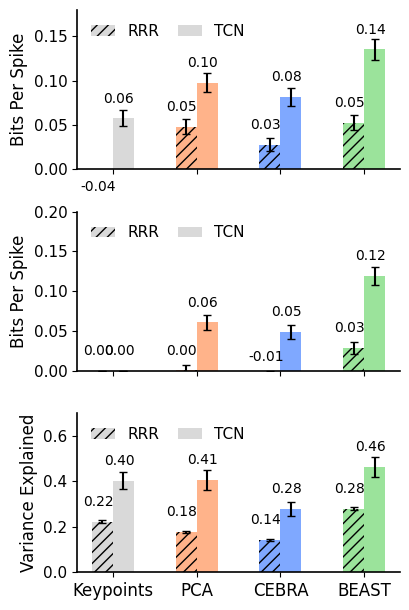

In [28]:
fig, axes = plot_bars(
    final_dict,
    model_order=("kp", "pca", "cebra", "beast"),
    model_display=("Keypoints", "PCA", "CEBRA", "BEAST"),
    dataset_names=("ibl-left", "ibl-whisker", "facemap"),  # <-- change to your actual keys
    ylabels=("Bits Per Spike", "Bits Per Spike", "Variance Explained"),
)
plt.show()